In [56]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

# import magnus
import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.oscprob.oscprobstd as oscprobstd
import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.hamiltonians.hamiltonians4nu as hamiltonians4nu
import magnus.hamiltonians.hamiltonians5nu as hamiltonians5nu
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

# 0. Helper functions and definitions

In [115]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

def flavor_index_to_str(nu_l):
    if (nu_l == gd.NUE): return 'e'
    if (nu_l == gd.NUMU): return 'mu'
    if (nu_l == gd.NUTAU): return 'tau'

# Plotting script for probabilities vs. baseline
def make_plot_prob_4nu_3nu_vs_baseline(nu_i, nu_f, distances, prob_4nu_all, prob_3nu_all, title=None, save_plot=True):
    
    heights = [1.0]
    widths = [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[18,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    prob_3nu = prob_3nu_all[:,nu_i,nu_f]
    prob_4nu = prob_4nu_all[:,nu_i,nu_f]

    ax.plot(distances, prob_4nu, lw=1, color='C1', ls='-', label='3+1 oscillations')
    ax.plot(distances, prob_3nu, lw=1, color='0.2', ls='--', label=r'Standard, $3\nu$')
    
    # Legend
    ax.legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7,
              borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)

    # Annotations # + r', $\delta_{14} = $~{:.2f}'.format(d14)
    ax.annotate(r'$s_{14} = $ '+str(s14) + r', $\delta_{14} = $ '+str(d14),
                xy = (0.02, 0.18), xycoords='axes fraction', ha='left', fontsize=18)
    ax.annotate(r'$s_{24} = $ '+str(s14) + r', $\delta_{24} = $ '+str(d14),
                xy = (0.02, 0.13), xycoords='axes fraction', ha='left', fontsize=18)
    ax.annotate(r'$s_{34} = $ '+str(s14),
                xy = (0.02, 0.08), xycoords='axes fraction', ha='left', fontsize=18)
    ax.annotate(r'$\Delta m_{41}^2 =$ '+str(D41)+r' eV$^2$',
                xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)

    # Formatting
    ax.set_ylabel(r'Probability,~'+prob_label(nu_i, nu_f), labelpad=25)
    ax.set_xlim(l_ini, l_fin)
    ax.set_ylim(0, 1)
    ax.set_xscale('log')
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    ax.set_xlabel(r'Baseline, $L$ [km]')
    if title is not None:
        ax.set_title(title, fontsize=23, pad=10)
    
    # Save plot
    plt.tight_layout()

    if save_plot:
        filename = 'prob_4nu_3nu_vs_baseline_'+flavor_index_to_str(nu_i)+'_'+flavor_index_to_str(nu_f)+'.'
        plt.savefig('../fig/'+filename+'.pdf', dpi=300)
        plt.savefig('../fig/'+filename+'.jpg', dpi=200)

# Plotting script for probabilities vs. energy
def make_plot_prob_4nu_3nu_vs_energy(nu_i, nu_f, energies, prob_4nu_all, prob_3nu_all, title=None, save_plot=True):
    
    heights = [1.0]
    widths = [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[18,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    prob_3nu = prob_3nu_all[:,nu_i,nu_f]
    prob_4nu = prob_4nu_all[:,nu_i,nu_f]

    ax.plot(energies, prob_4nu, lw=1, color='C1', ls='-', label='3+1 oscillations')
    ax.plot(energies, prob_3nu, lw=1, color='0.2', ls='--', label=r'Standard, $3\nu$')

    # Legend
    ax.legend(fontsize=17, frameon=True, loc='center right', handlelength=1.2, handleheight=0.7,
                 borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)

    # Annotations # + r', $\delta_{14} = $~{:.2f}'.format(d14)
    ax.annotate(r'$s_{14} = $ '+str(s14) + r', $\delta_{14} = $ '+str(d14),
                xy = (0.02, 0.18), xycoords='axes fraction', ha='left', fontsize=18)
    ax.annotate(r'$s_{24} = $ '+str(s14) + r', $\delta_{24} = $ '+str(d14),
                xy = (0.02, 0.13), xycoords='axes fraction', ha='left', fontsize=18)
    ax.annotate(r'$s_{34} = $ '+str(s14),
                xy = (0.02, 0.08), xycoords='axes fraction', ha='left', fontsize=18)
    ax.annotate(r'$\Delta m_{41}^2 =$ '+str(D41)+r' eV$^2$',
                xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)

    # Formatting
    ax.set_ylabel(r'Probability,~'+prob_label(nu_i, nu_f), labelpad=25)
    ax.set_xlim(energy_min, energy_max)
    ax.set_ylim(0, 1)
    ax.set_xscale('log')
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    ax.set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
    if title is not None:
        ax.set_title(title, fontsize=23, pad=10)

    # Save plot
    plt.tight_layout()

    if save_plot:
        filename = 'prob_4nu_3nu_vs_energy_'+flavor_index_to_str(nu_i)+'_'+flavor_index_to_str(nu_f)+'.'
        plt.savefig('../fig/'+filename+'.pdf', dpi=300)
        plt.savefig('../fig/'+filename+'.jpg', dpi=200)

# 1. Probabilities in a 3+1 system ($4\nu$): in vacuum

### 1.1 General definitions

In [3]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 0.5 # [eV^2]

### 1.2 Probabilities vs. distance

Generate probabilities

In [110]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: 
# [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# For the 4nu case, osc_prob returns a 3x3 NumPy array with the probabilities:
# [[Pee, Pem, Pet, Pes], [Pme, Pmm, Pmt, Pms], [Pte, Ptm, Ptt, Pts]]

# Standard, 3nu probabilities
H_3nu_vac = hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, compute_matrix_multiplication=False)
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: H_3nu_vac, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

# 3+1 probabilities
H_4nu_vac = hamiltonians4nu.hamiltonian_4nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                   compute_matrix_multiplication=False)
prob_4nu_all = np.array([oscprob.osc_prob(lambda l: H_4nu_vac, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

Plot probabilities

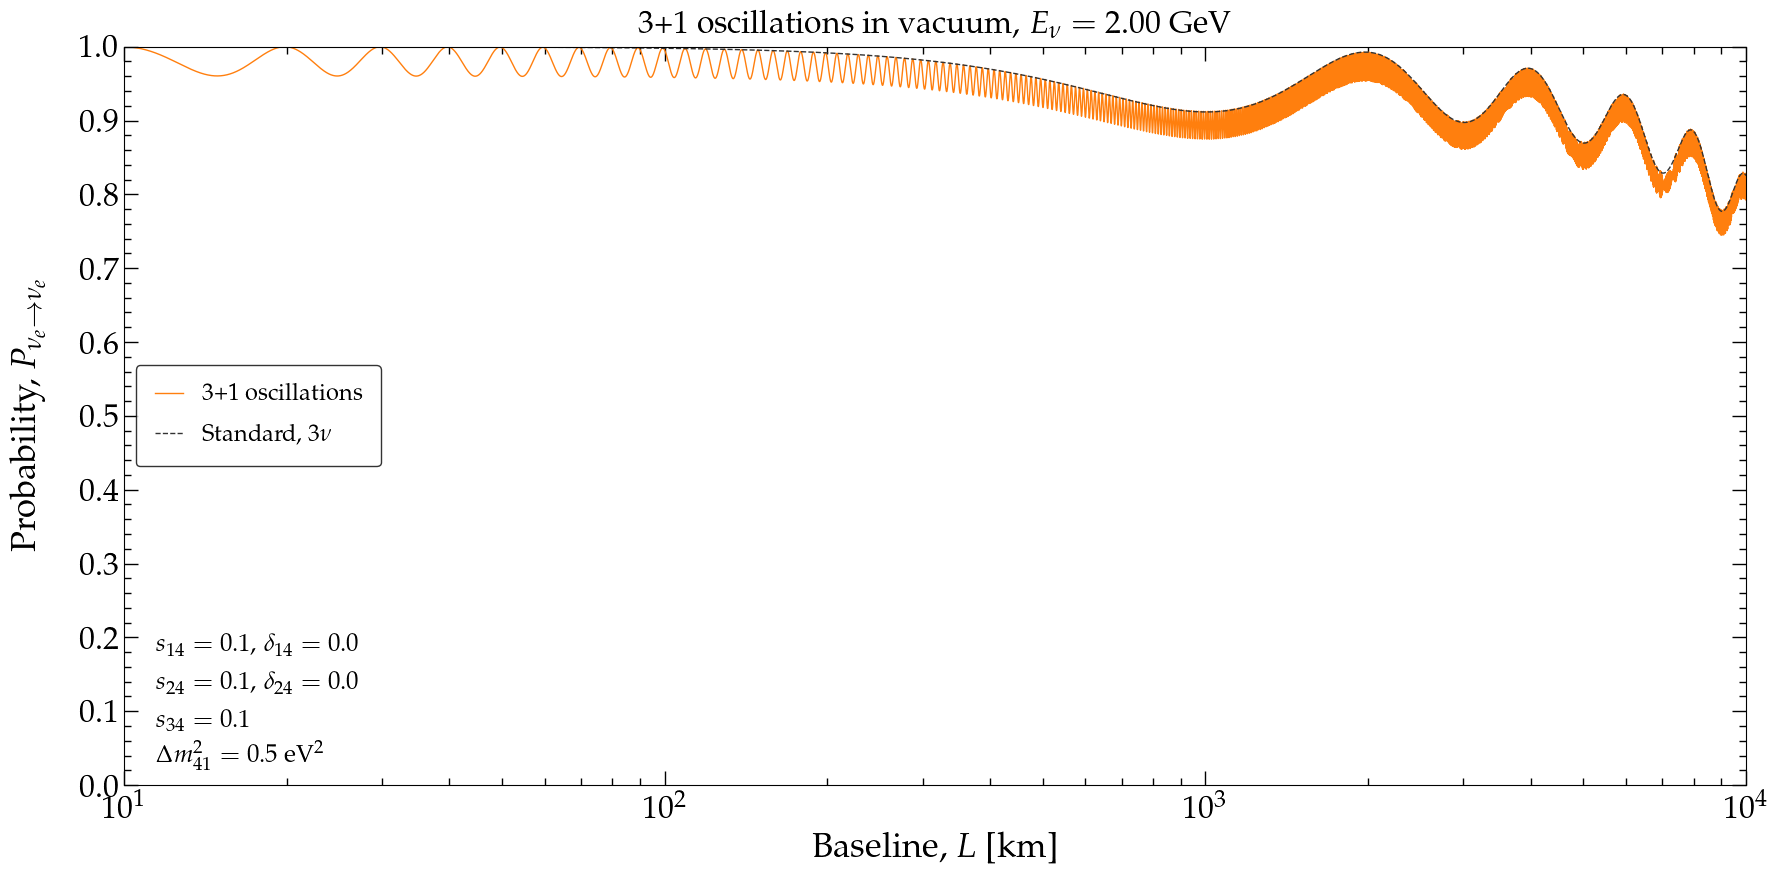

In [111]:
make_plot_prob_4nu_3nu_vs_baseline(gd.NUE, gd.NUE, distances, prob_4nu_all, prob_3nu_all, 
                                   title=r'3+1 oscillations in vacuum, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

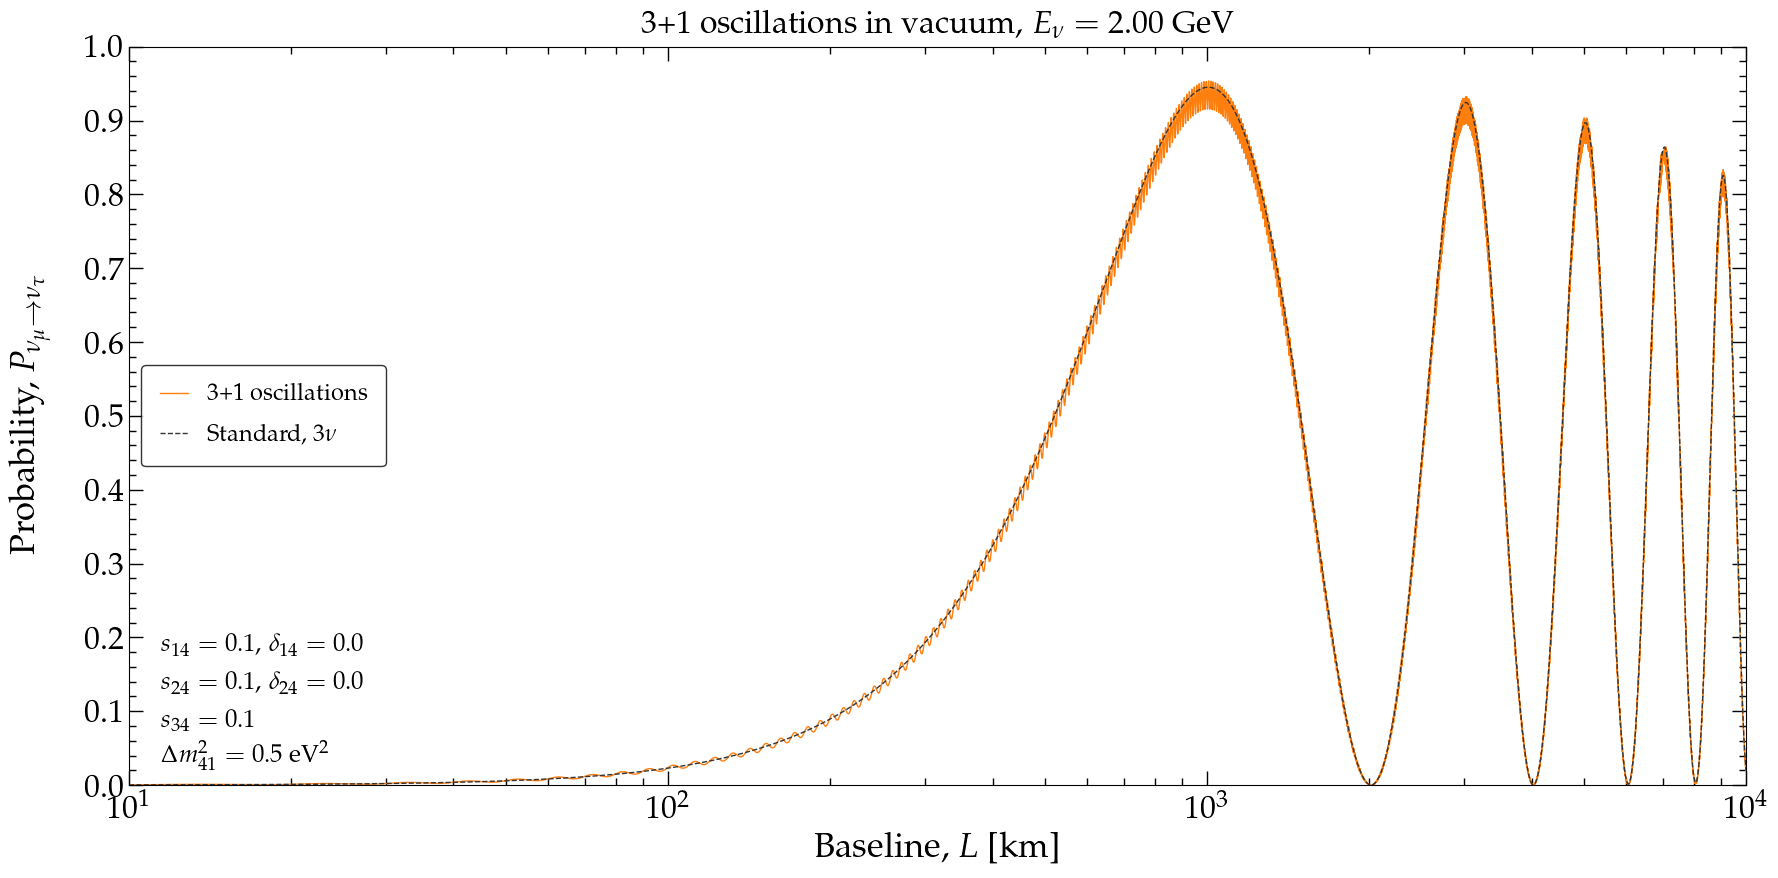

In [112]:
make_plot_prob_4nu_3nu_vs_baseline(gd.NUMU, gd.NUTAU, distances, prob_4nu_all, prob_3nu_all, 
                                   title=r'3+1 oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline), save_plot=False)

### 1.3 Probabilities vs. energy

Generate probabilities

In [117]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Standard, 3nu probabilities
H_3nu_vac_en_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False) # Vacuum H without (1/E)
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_3nu_vac_en_indep, 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# 3+1 probabilities
H_4nu_vac_en_indep = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                                               compute_matrix_multiplication=False) 
prob_4nu_all = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_4nu_vac_en_indep, 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

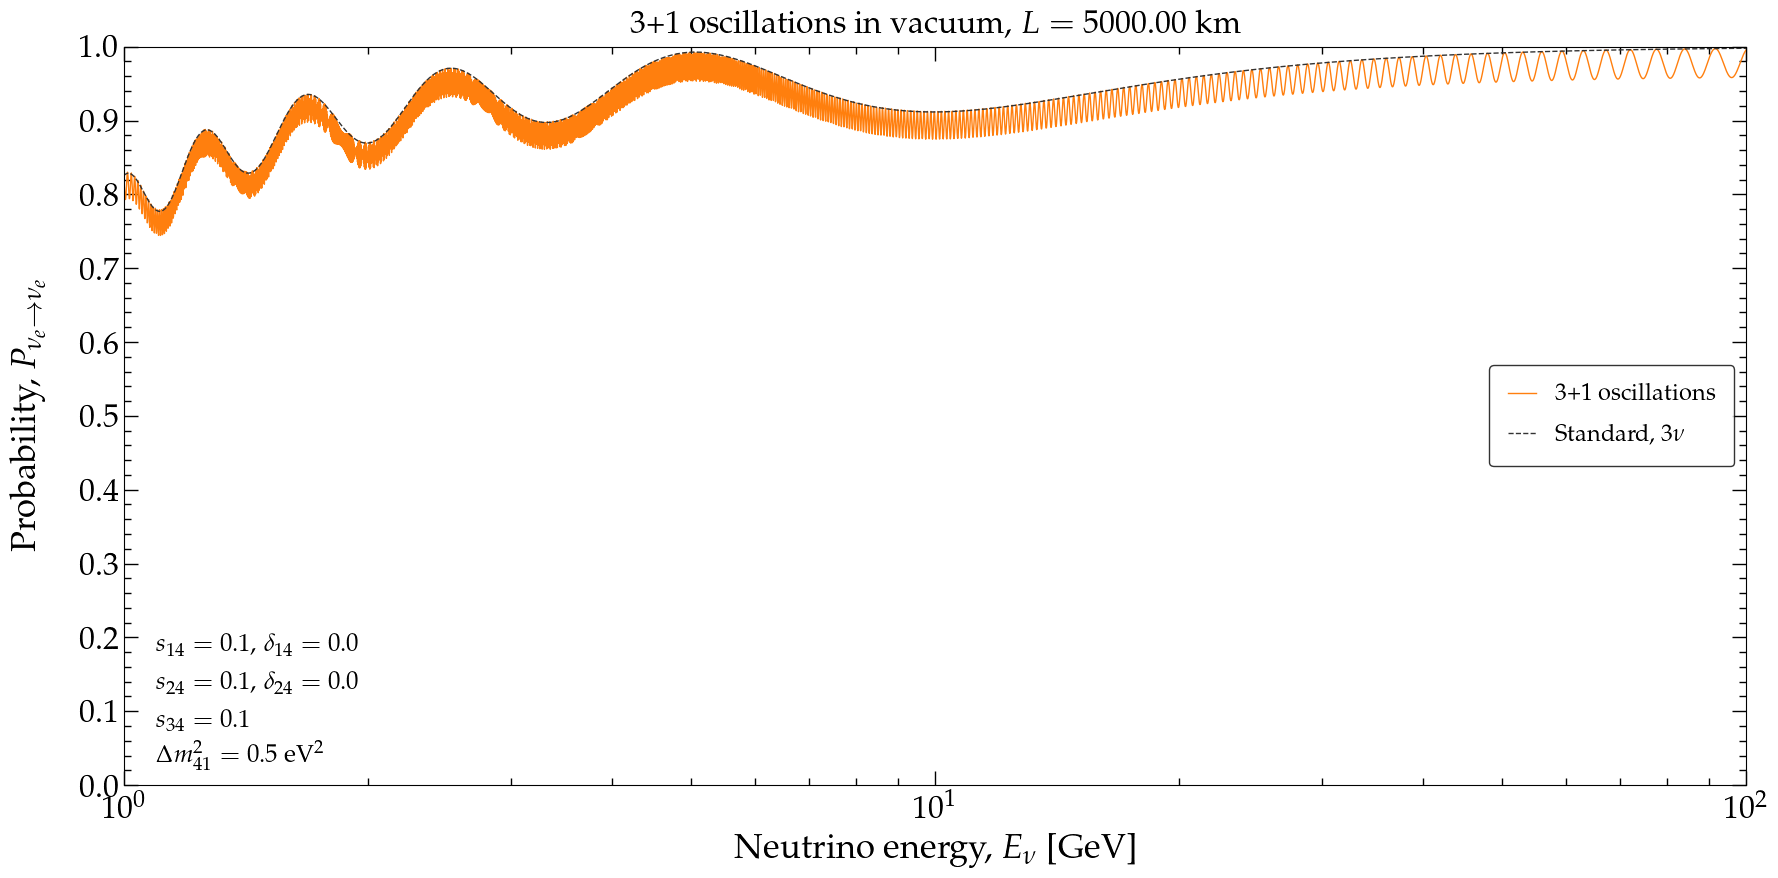

In [118]:
make_plot_prob_4nu_3nu_vs_energy(gd.NUE, gd.NUE, energies, prob_4nu_all, prob_3nu_all,
                                 title=r'3+1 oscillations in vacuum, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

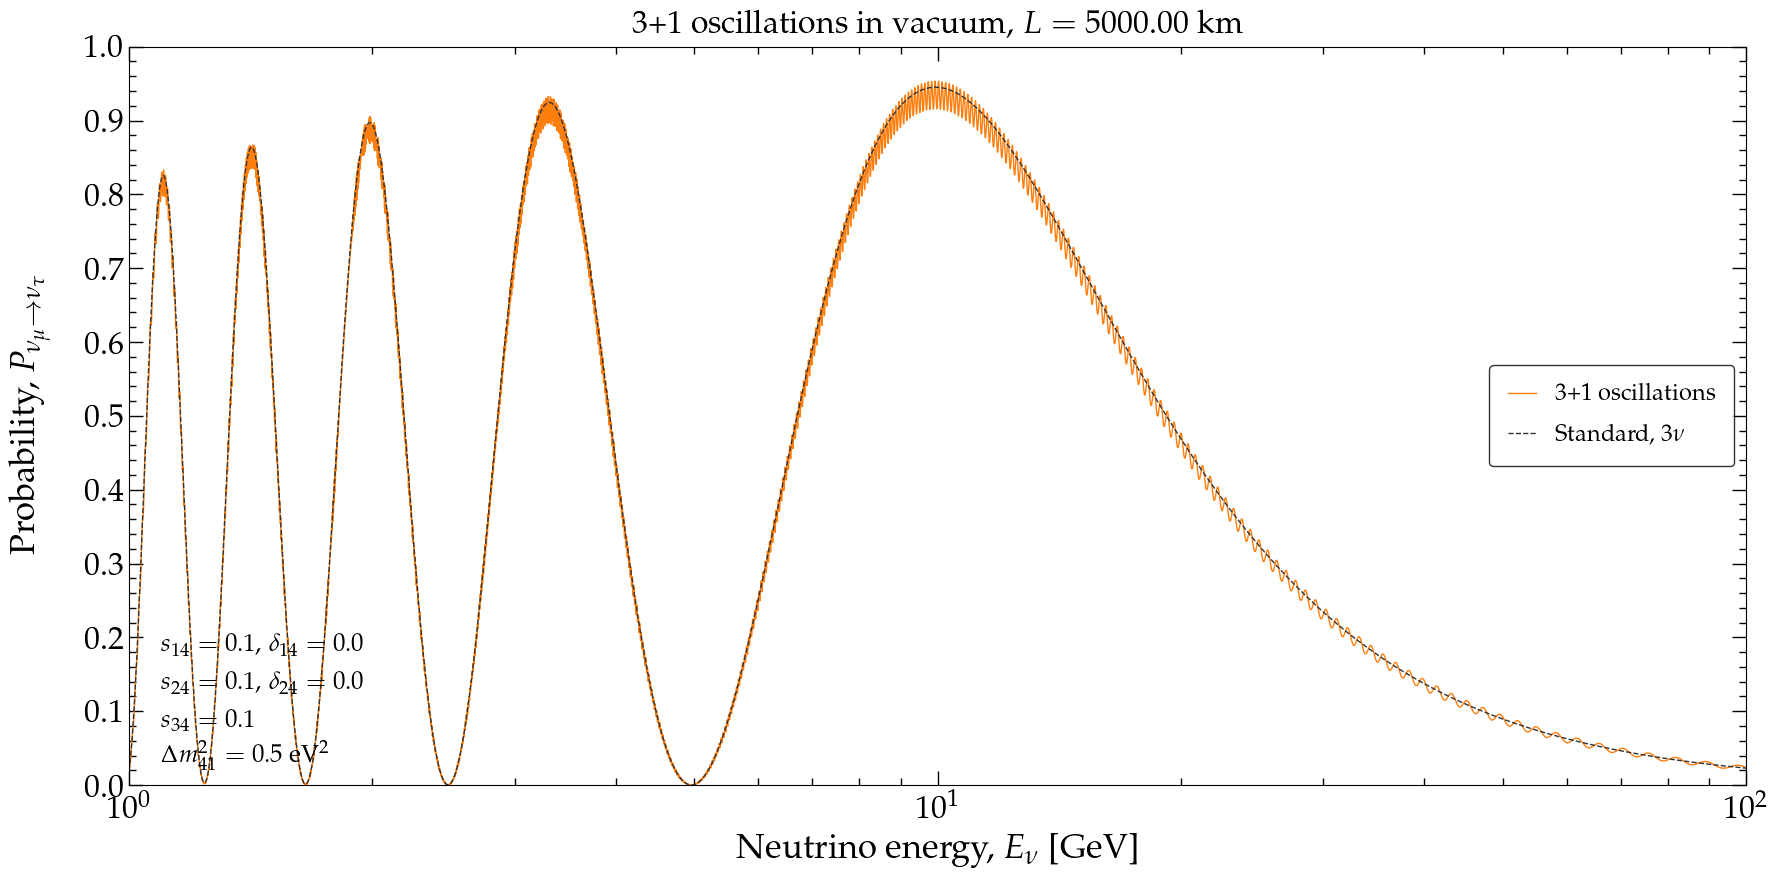

In [119]:
make_plot_prob_4nu_3nu_vs_energy(gd.NUMU, gd.NUTAU, energies, prob_4nu_all, prob_3nu_all, 
                                 title=r'3+1 oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline), save_plot=False)

# 2. Probabilities in a 3+1 system ($4\nu$): in matter with constant density

### 2.1 General definitions

In [4]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 0.5 # [eV^2]

### 2.2 Probabilities vs. distance

Generate probabilities

In [21]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: 
# [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# For the 4nu case, osc_prob returns a 3x3 NumPy array with the probabilities:
# [[Pee, Pem, Pet, Pes], [Pme, Pmm, Pmt, Pms], [Pte, Ptm, Ptt, Pts]]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Standard, 3nu probabilities
H_3nu_vac = hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, compute_matrix_multiplication=False)
H_3nu_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)
H_3nu = lambda l: H_3nu_vac - H_3nu_matt
prob_3nu_all = np.array([oscprob.osc_prob(H_3nu, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

# 3+1 probabilities
H_4nu_vac = hamiltonians4nu.hamiltonian_4nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                   compute_matrix_multiplication=False)
H_4nu_matt = hamiltonians4nu.hamiltonian_4nu_matter(VCC)
H_4nu = lambda l: H_4nu_vac - H_4nu_matt
prob_4nu_all = np.array([oscprob.osc_prob(H_4nu, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

Plot probabilities

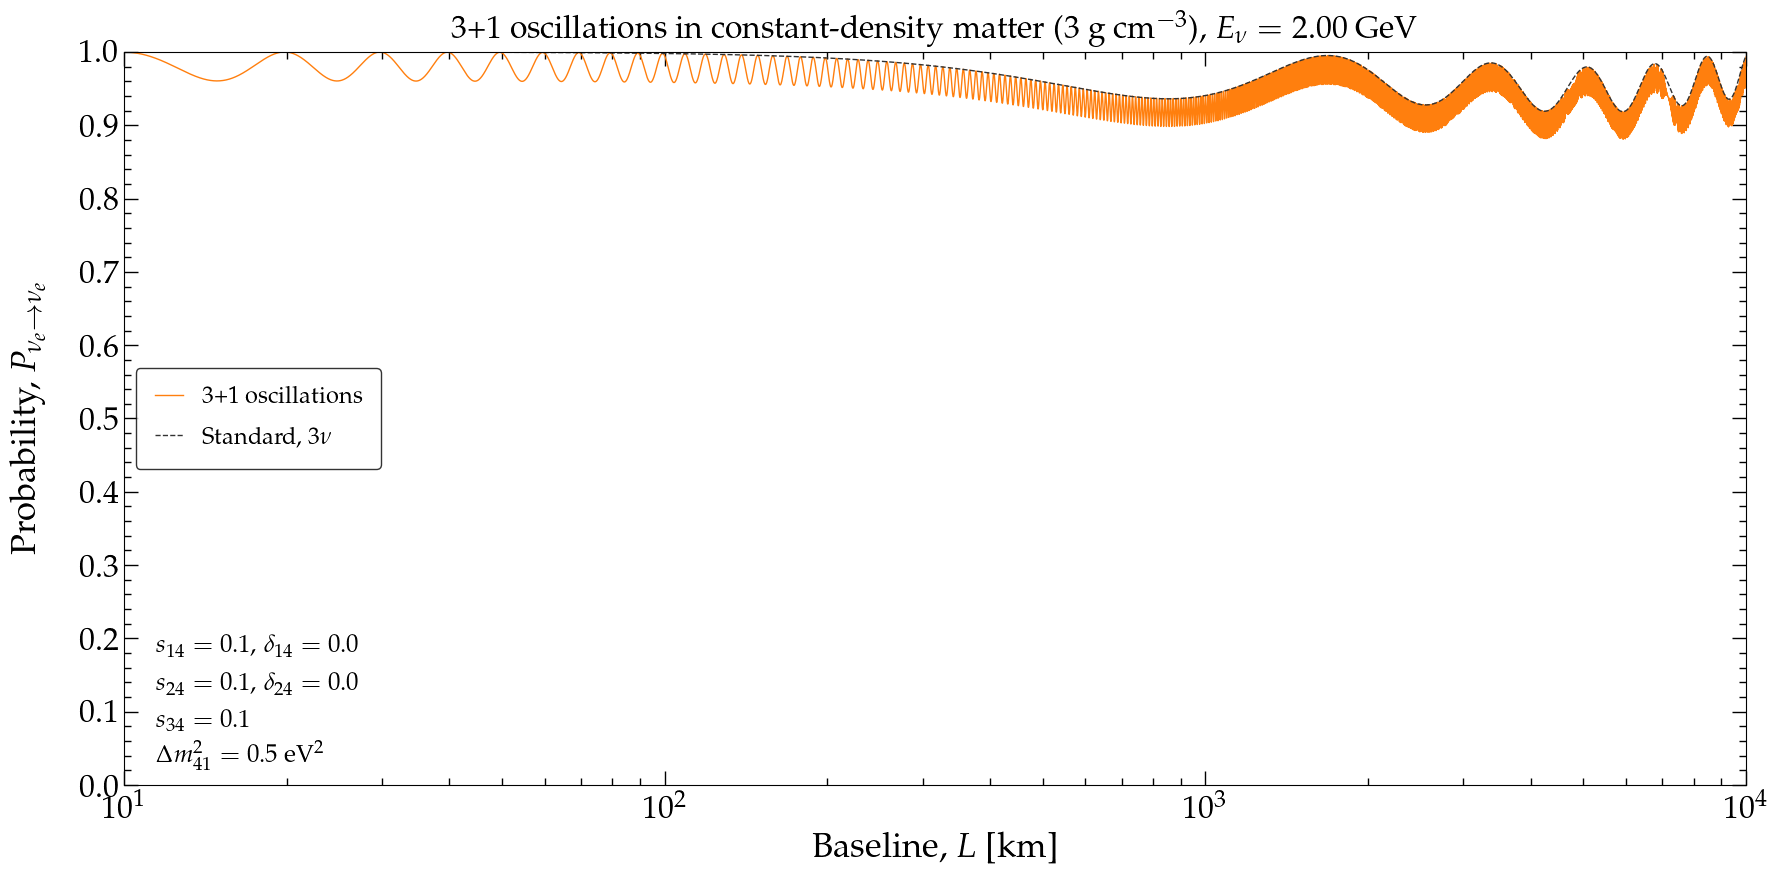

In [26]:
make_plot_prob_4nu_3nu_vs_baseline(gd.NUE, gd.NUE, distances, prob_4nu_all, prob_3nu_all,
                                   title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

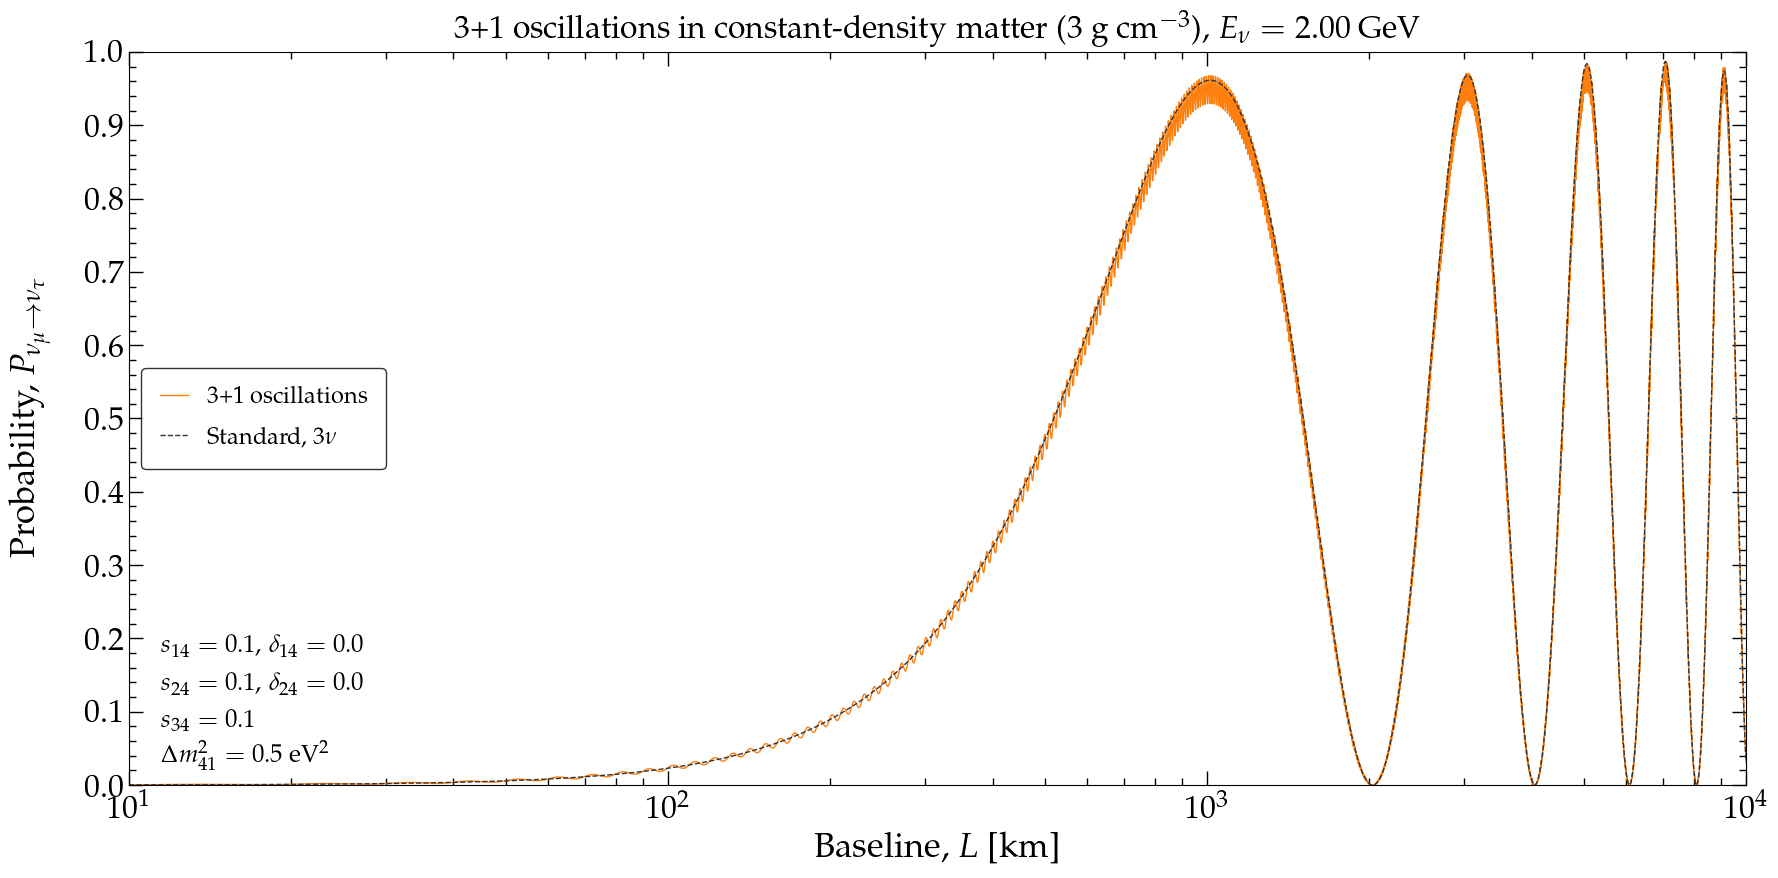

In [27]:
make_plot_prob_4nu_3nu_vs_baseline(gd.NUMU, gd.NUTAU, distances, prob_4nu_all, prob_3nu_all,
                                   title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

### 2.3 Probabilities vs. energy

Generate probabilities

In [48]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Standard, 3nu probabilities
H_3nu_vac_en_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False)
H_3nu_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)
def H_3nu(energy, l):
    return (1/energy)*H_3nu_vac_en_indep - H_3nu_matt
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: H_3nu(enu*gd.UNIT_GEV, l), 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# 3+1 probabilities
H_4nu_vac_en_indep = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                   compute_matrix_multiplication=False)
H_4nu_matt = hamiltonians4nu.hamiltonian_4nu_matter(VCC)
def H_4nu(energy, l):
    return (1/energy)*H_4nu_vac_en_indep - H_4nu_matt
prob_4nu_all = np.array([oscprob.osc_prob(lambda l: H_4nu(enu*gd.UNIT_GEV, l), 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

Plot probabilities

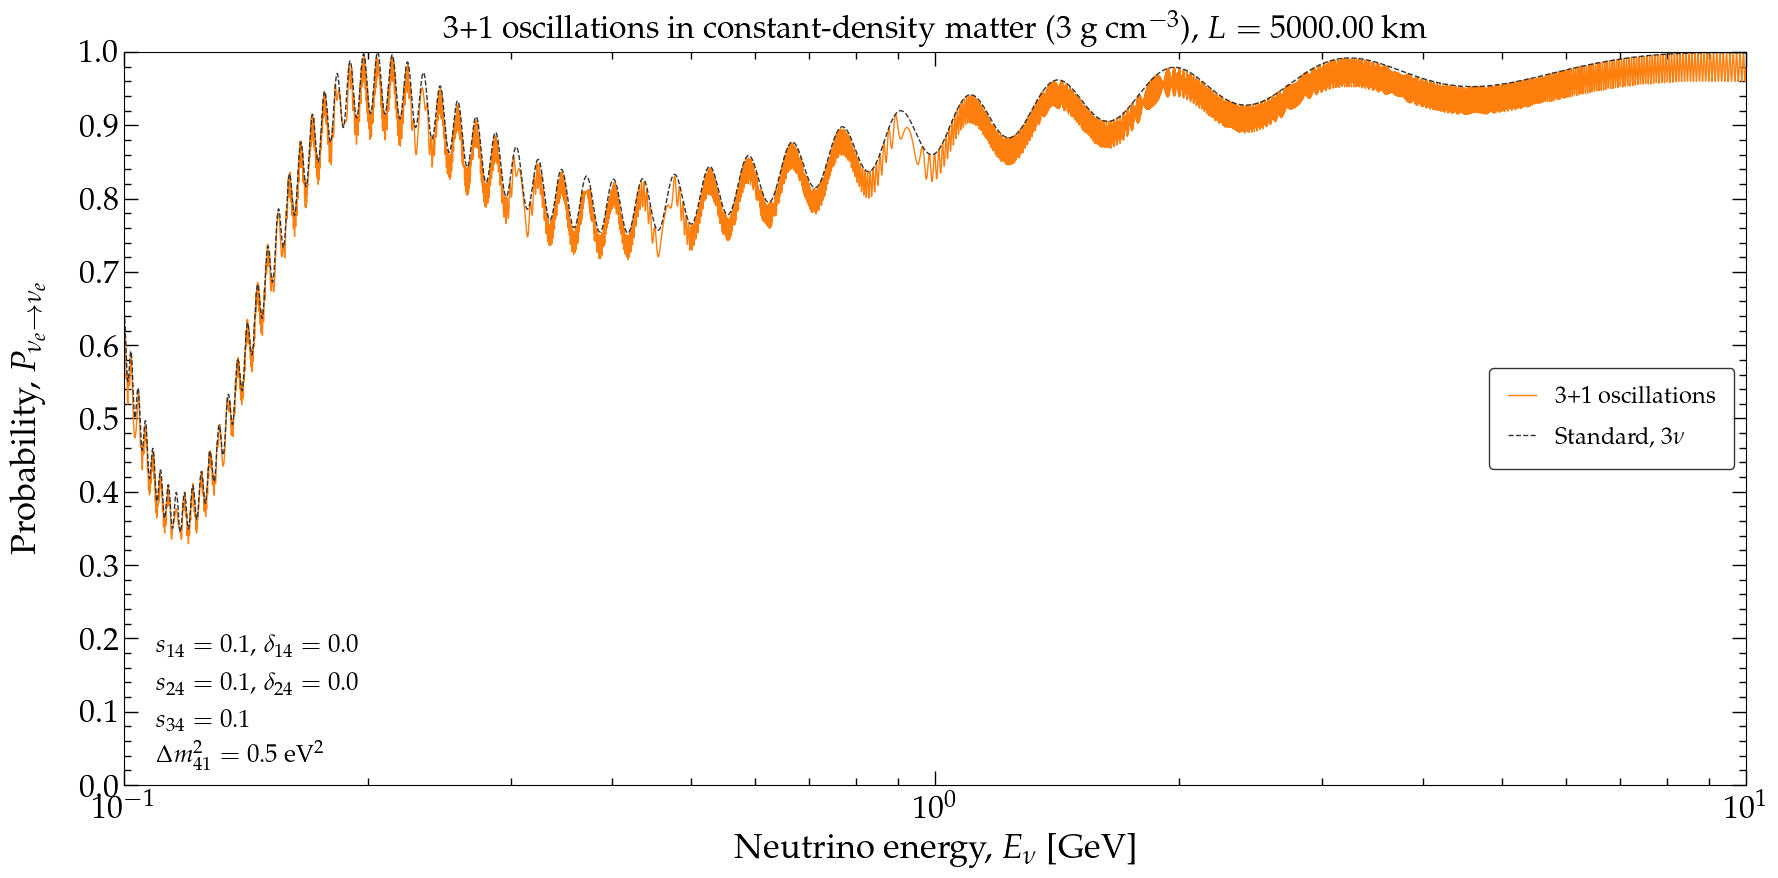

In [49]:
make_plot_prob_4nu_3nu_vs_energy(gd.NUE, gd.NUE, energies, prob_4nu_all, prob_3nu_all,
                                 title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                       r'$L = $~{:.2f}~km'.format(baseline), save_plot=False)

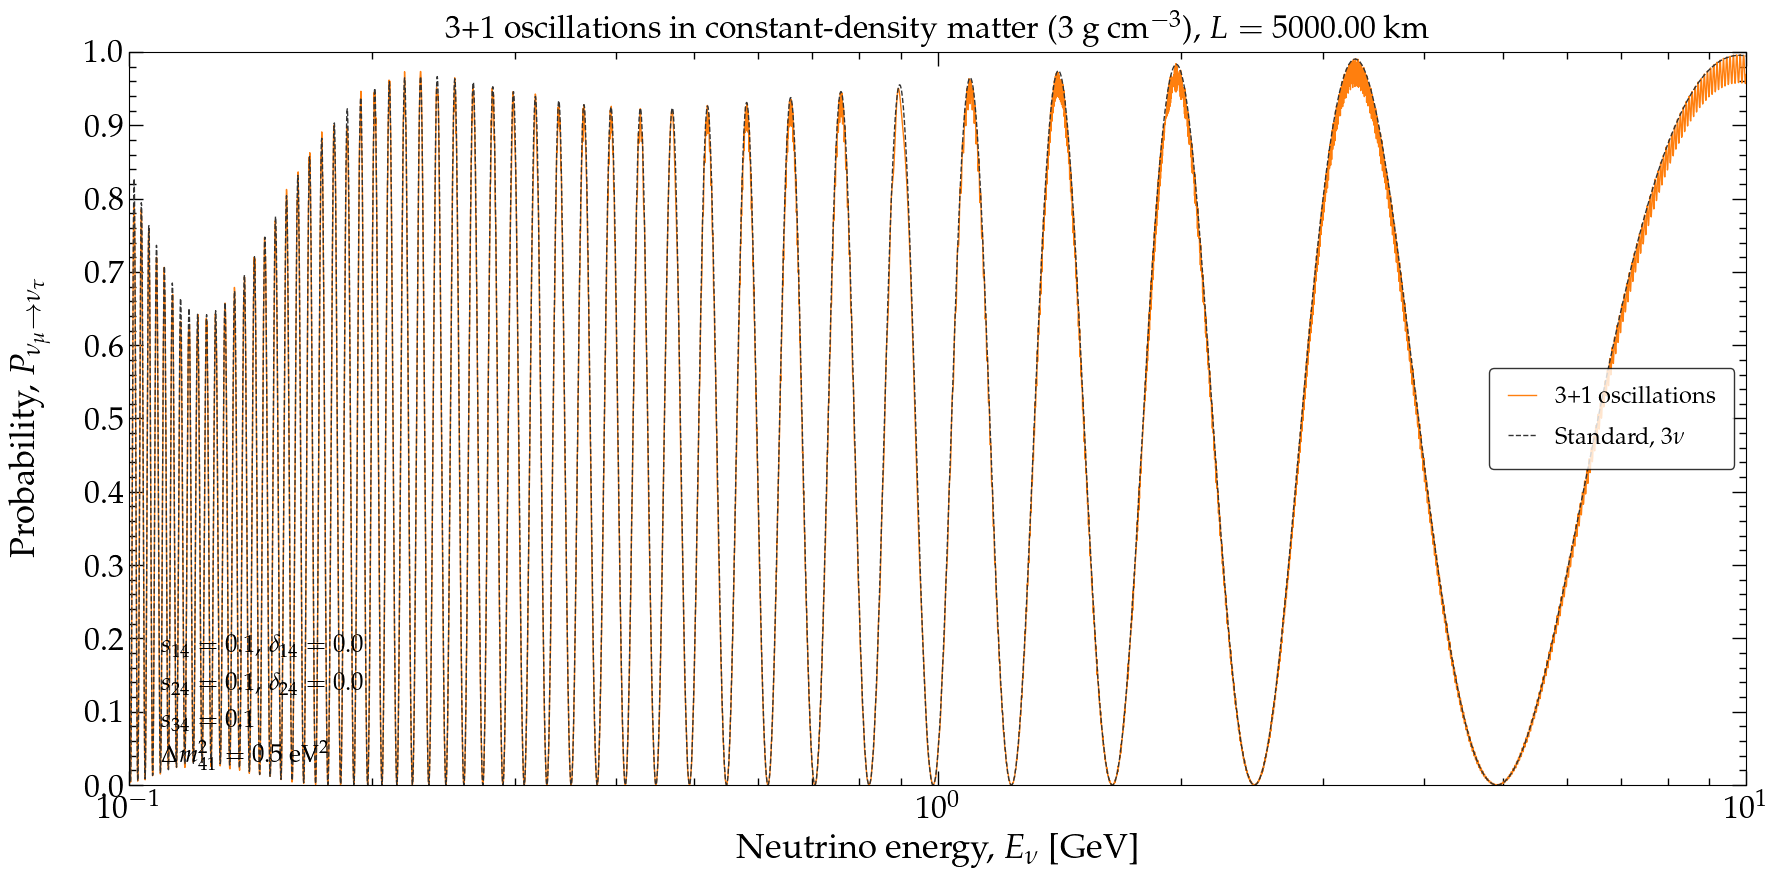

In [50]:
make_plot_prob_4nu_3nu_vs_energy(gd.NUMU, gd.NUTAU, energies, prob_4nu_all, prob_3nu_all,
                                 title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                       r'$L = $~{:.2f}~km'.format(baseline), save_plot=False)

# 3. Probabilities in a 3+1 system ($4\nu$): long-baseline inside Earth (PREM)

For more details about computing and plotting probabilities in long-baseline experimental setups, see notebook `04_magnus_long_baseline.ipynb`.

### 3.1 General definitions

In [58]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Electron number density inside Earth, using the PREM density model
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5) # [eV^{-3}]

# Coherent forward potential inside Earth, using the PREM density model
def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

# Cosines of zenith angles of Fermilab measured from the detector locations (we would get the same result if we seapped them, since we
# consider that Earth is radially symmetric)
detectors = ['SNOLAB', 'Homestake', 'CERN', "South Pole"]
costhz_arr = [earth.costhz_between_points_on_surface(earth.loc_coords_dms[det.lower().replace(" ", "_")]['lat'], 
                                                     earth.loc_coords_dms[det.lower().replace(" ", "_")]['lon'],
                                                     earth.loc_coords_dms['fermilab']['lat'], 
                                                     earth.loc_coords_dms['fermilab']['lon']) 
             for det in detectors]

# Maximum baselines inside the Earth
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] # [km]

### 3.2 Probabilities vs. energy

Define the Hamiltonians

In [101]:
# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 2.e-1 # [adim]
d14 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 0.5 # [eV^2]

# Vacuum Hamiltonian without the 1/E prefactor 
H_3nu_vac_en_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False)
H_4nu_vac_en_indep = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                                               compute_matrix_multiplication=False)

# Hamiltonian including matter effects inside Earth using the PREM density model
def H_3nu_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return (1/energy)*H_3nu_vac_en_indep - hamiltonians3nu.hamiltonian_3nu_matter(VCC_func_prem(r/gd.CONV_KM_TO_INV_EV))
    
def H_4nu_prem(costhz, l, energy):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return (1/energy)*H_4nu_vac_en_indep - hamiltonians4nu.hamiltonian_4nu_matter(VCC_func_prem(r/gd.CONV_KM_TO_INV_EV))

Generate the probabilities

In [102]:
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 3000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Generate probabilities for the different directions
prob_3nu_arr, prob_4nu_arr = [], []
for i in range(len(costhz_arr)):
    print("detector = " + detectors[i])
    prob_3nu = np.array([oscprob.osc_prob(lambda l: H_3nu_prem(costhz_arr[i], l, enu*gd.UNIT_MEV), 
                                          0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                          n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_4nu = np.array([oscprob.osc_prob(lambda l: H_4nu_prem(costhz_arr[i], l, enu*gd.UNIT_MEV), 
                                          0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                          n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_3nu_arr.append(prob_3nu)
    prob_4nu_arr.append(prob_4nu)

detector = SNOLAB
detector = Homestake
detector = CERN
detector = South Pole


Plot the probabilities

Text(0, 0.5, 'Probability,~$P_{\\nu_e \\to \\nu_e}$')

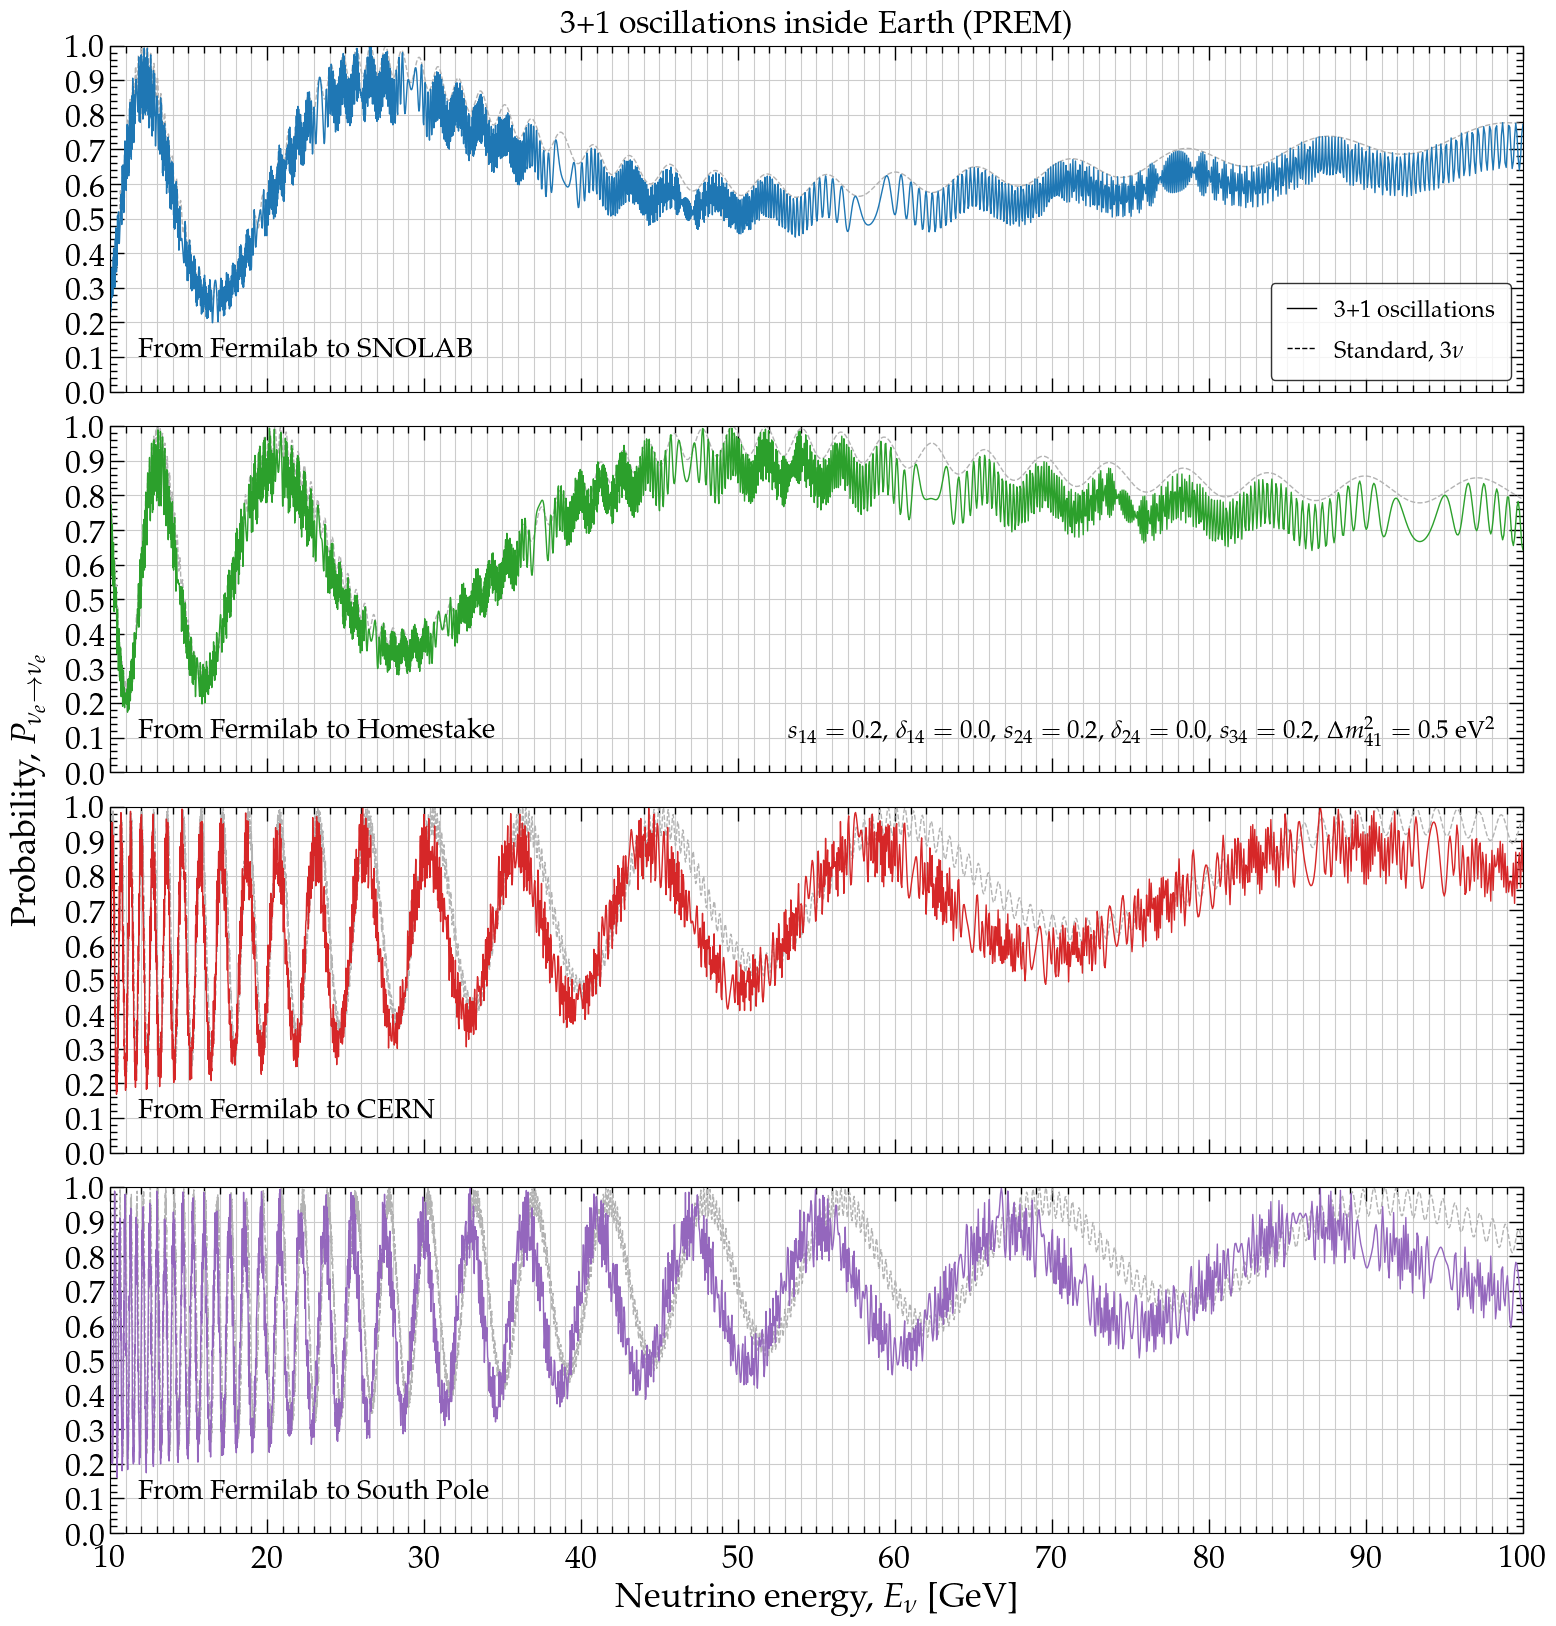

In [103]:
heights = [1.0, 1.0, 1.0, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=4, 
    gridspec_kw=gs_kw, 
    figsize=[18,18])
fig.subplots_adjust(hspace=0.1, wspace=0.1)

lc = ['C0', 'C2', 'C3', 'C4']

# Probabilities
for i in range(len(costhz_arr)):
    ax[i].plot(energies, prob_3nu_arr[i], lw=1, c='0.7', ls='--')
    ax[i].plot(energies, prob_4nu_arr[i], lw=1, c=lc[i], ls='-')

# # Legend
ax[0].plot([-1,-1], [-1,-1], lw=1, c='k', ls='-', label=r'3+1 oscillations')
ax[0].plot([-1,-1], [-1,-1], lw=1, c='k', ls='--', label=r'Standard, $3\nu$')
ax[0].legend(fontsize=17, frameon=True, loc='lower right', handlelength=1.2, handleheight=0.7,
             borderpad=0.7, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)

# Annotations
ax[1].annotate(r'$s_{14} = $ '+str(s14) + r', $\delta_{14} = $ '+str(d14) + \
               r', $s_{24} = $ '+str(s14) + r', $\delta_{24} = $ '+str(d14) + \
               r', $s_{34} = $ '+str(s14) + r', $\Delta m_{41}^2 =$ '+str(D41)+r' eV$^2$',
               xy = (0.98, 0.10), xycoords='axes fraction', ha='right', fontsize=18)

# Formatting
for i, axx in enumerate(ax):
    axx.set_xlim(energy_min, energy_max)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
    axx.set_ylim(0, 1)
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    if (i != 3):
        axx.xaxis.set_ticklabels([])
    axx.annotate(r'From Fermilab to '+detectors[i], xy = (0.02, 0.10), xycoords='axes fraction', ha='left', fontsize=20)
ax[0].set_title(r'3+1 oscillations inside Earth (PREM)', fontsize=23, pad=10)
ax[3].set_xlabel(r'Neutrino energy, $E_\nu$~[GeV]')

# Common y-axis label
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
plt.ylabel(r'Probability,~'+prob_label(nu_i, nu_f), labelpad=15)

### 3.3 Probabilities vs. active-sterile mixing parameter

Let's pick a baseline from Fermilab to Homestake (i.e., DUNE), which is about 1300 km, and see how the probability changes with the value of one of the active-sterile mixing parameters.  This is part of the analysis chain used to place bounds on the values of sterile neutrino mixing parameters.

Generate the probabilities

In [167]:
nu_i, nu_f = gd.NUMU, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Energies
energy = 2.0*gd.UNIT_GEV # [eV]

# Zenith angle corresponding to Fermilab-Homestake (already computed above)
costhz = costhz_arr[1]

# Chord length Fermilab-Homestake
l_max = l_max_arr[1] # [km]

# Fixed mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
# s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 1.e3 # [eV^2]

# Active-sterile mixing parameters that we vary
s24_npts = 100
s24_arr = np.linspace(0.0, 1.0, s24_npts) # [adim]
D41_arr = [1.e-2, 1.e-1, 1.e0, 1.e1] # [eV^2]
D41_label = [r'$\Delta m_{41}^2 = 0.01$~eV$^2$', r'$\Delta m_{41}^2 = 0.1$~eV$^2$', r'$\Delta m_{41}^2 = 1$~eV$^2$', 
             r'$\Delta m_{41}^2 = 10$~eV$^2$']

# Hamiltonian including matter effects inside Earth using the PREM density model
def H_3nu_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31) \
            - hamiltonians3nu.hamiltonian_3nu_matter(VCC_func_prem(r/gd.CONV_KM_TO_INV_EV))
    
def H_4nu_prem(costhz, l, energy, s14, d14, s24, d24, s34, D21, D31, D41):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return hamiltonians4nu.hamiltonian_4nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41) \
            - hamiltonians4nu.hamiltonian_4nu_matter(VCC_func_prem(r/gd.CONV_KM_TO_INV_EV))

Generate the probabilities

In [168]:
prob_3nu = oscprob.osc_prob(lambda l: H_3nu_prem(costhz, l, energy), 
                                      0, l_max*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f]

prob_4nu = np.array([[oscprob.osc_prob(lambda l: H_4nu_prem(costhz, l, energy, s14, d14, s24, d24, s34, D21, D31, D41), 
                                      0, l_max*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for s24 in s24_arr]
                     for D41 in D41_arr]) 

Plot the probabilities

Text(0.5, 1.0, '3+1 oscillations from Fermilab to Homestake, $E_\\nu = $~2.00~GeV')

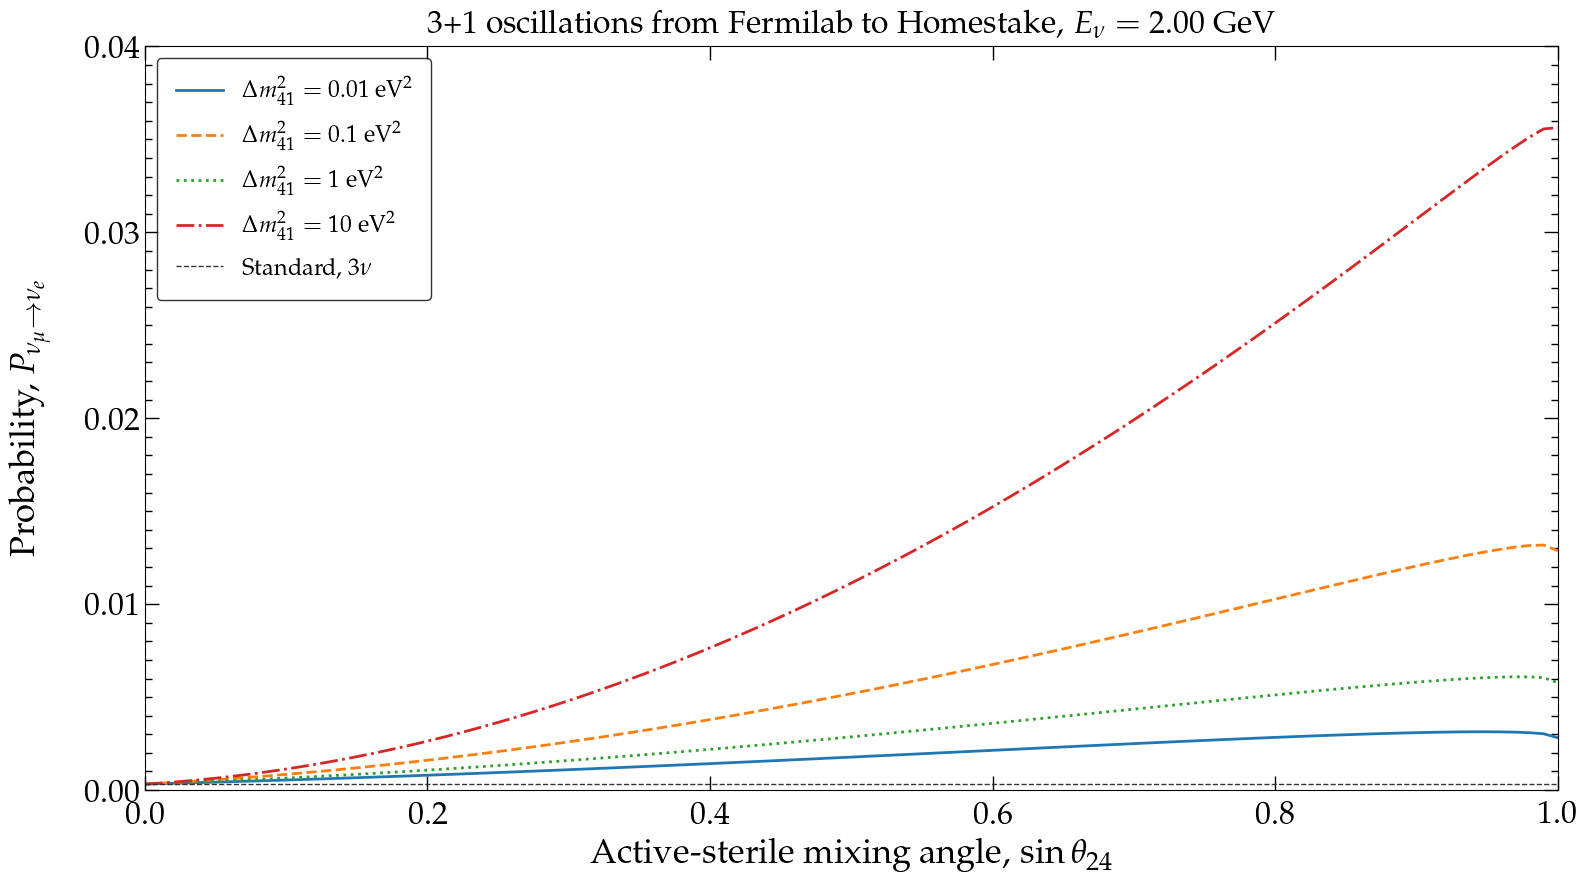

In [169]:
heights = [1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=1, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

lc = ['C0', 'C1', 'C2', 'C3']
ls = ['-', '--', ':', '-.']
for i in range(len(D41_arr)):
    ax.plot(s24_arr, prob_4nu[i], lw=2, color=lc[i], ls=ls[i], label=D41_label[i])
ax.plot([s24_arr[0], s24_arr[-1]], [prob_3nu, prob_3nu], lw=1, color='0.2', ls='--', label=r'Standard, $3\nu$')

# Legend
ax.legend(fontsize=17, frameon=True, loc='upper left', handlelength=2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)

# Annotations # + r', $\delta_{14} = $~{:.2f}'.format(d14)
# ax.annotate(r'$s_{14} = $ '+str(s14) + r', $\delta_{14} = $ '+str(d14),
#             xy = (0.02, 0.18), xycoords='axes fraction', ha='left', fontsize=18)
# ax.annotate(r'$s_{24} = $ '+str(s14) + r', $\delta_{24} = $ '+str(d14),
#             xy = (0.02, 0.13), xycoords='axes fraction', ha='left', fontsize=18)
# ax.annotate(r'$s_{34} = $ '+str(s14),
#             xy = (0.02, 0.08), xycoords='axes fraction', ha='left', fontsize=18)
# ax.annotate(r'$\Delta m_{41}^2 =$ '+str(D41)+r' eV$^2$',
#             xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)

# Formatting
ax.set_xlabel(r'Active-sterile mixing angle, $\sin \theta_{24}$')
ax.set_ylabel(r'Probability,~'+prob_label(nu_i, nu_f), labelpad=25)
ax.set_xlim(s24_arr[0], s24_arr[-1])
ax.set_ylim(0, 0.04)
# ax.set_xscale('log')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.01))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.001))
ax.set_title(r'3+1 oscillations from Fermilab to Homestake, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), fontsize=23, pad=10)

# 4. Probabilities in a 3+2 system ($5\nu$)